### 1-2. 데이터 분석 및 시각화

다음 내용을 분석하고 시각화하여 데이터의 특징을 작성
- 데이터 기본 정보
- 각 컬럼의 데이터 분포
- 클래스(Target) 분포
- 변수 간 상관관계
- 주요 변수별 시각화(Histogram, Boxplot 등)

In [92]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

plt.rcParams['font.family'] = 'AppleGothic'

In [23]:


df = pd.read_csv("netflix_movies_detailed_up_to_2025.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,NaN,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000,752600867
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,NaN,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000,839030630
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,NaN,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000,954305868
3,38757,Movie,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,7.600,NaN,"Animation, Family, Adventure",en,"Feisty teenager Rapunzel, who has long and mag...",111.762,11638,7.600,260000000,592461732
4,10191,Movie,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,7.800,NaN,"Fantasy, Adventure, Animation, Family",en,As the son of a Viking leader on the cusp of m...,110.044,13259,7.800,165000000,494879471


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16000 non-null  int64  
 1   type          16000 non-null  object 
 2   title         16000 non-null  object 
 3   director      15868 non-null  object 
 4   cast          15796 non-null  object 
 5   country       15534 non-null  object 
 6   date_added    16000 non-null  object 
 7   release_year  16000 non-null  int64  
 8   rating        16000 non-null  float64
 9   duration      0 non-null      float64
 10  genres        15893 non-null  object 
 11  language      16000 non-null  object 
 12  description   15868 non-null  object 
 13  popularity    16000 non-null  float64
 14  vote_count    16000 non-null  int64  
 15  vote_average  16000 non-null  float64
 16  budget        16000 non-null  int64  
 17  revenue       16000 non-null  int64  
dtypes: float64(4), int64(5), o

| **컬럼명 (Column)** | **데이터 타입 (Dtype)** | **설명 (Description)** |
| --- | --- | --- |
| **`show_id`** | `int64` | 영화 고유 식별 번호 |
| **`type`** | `object` | 콘텐츠 유형 (모두 Movie로 구성) |
| **`title`** | `object` | 영화 제목 |
| **`director`** | `object` | 연출 감독 이름 |
| **`cast`** | `object` | 주요 출연 배우 목록 |
| **`country`** | `object` | 제작 국가 |
| **`date_added`** | `object` | 플랫폼 등록 날짜 (YYYY-MM-DD) |
| **`release_year`** | `int64` | 영화 개봉 연도 |
| **`rating`** | `float64` | 작품 평점 수치 |
| **`duration`** | `float64` | 상영 시간 (전건 결측치) |
| **`genres`** | `object` | 영화 장르 (쉼표 구분의 다중 장르) |
| **`language`** | `object` | 영화 주요 언어 코드 |
| **`description`** | `object` | 영화 줄거리 요약 |
| **`popularity`** | `float64` | TMDB 플랫폼 내 인기도 지표 |
| **`vote_count`** | `int64` | 평점 투표 참여 인원수 |
| **`vote_average`** | `float64` | 평균 사용자 평점 수치 |
| **`budget`** | `int64` | 영화 제작 예산 (USD) |
| **`revenue`** | `int64` | 박스오피스 총수익 (USD) |

In [25]:
key_numeric_cols = [
    "vote_average",
    "budget",
    "revenue",
    "popularity",
    "vote_count",
]

display(df[key_numeric_cols].describe())

,vote_average,budget,revenue,popularity,vote_count
count,16000.000000,1.600000e+04,1.600000e+04,16000.000000,16000.000000
mean,5.956368,8.766792e+06,2.446308e+07,20.384728,718.656125
std,1.754741,2.912450e+07,1.116977e+08,68.610033,2080.198316
min,0.000000,0.000000e+00,0.000000e+00,3.860000,0.000000
25%,5.600000,0.000000e+00,0.000000e+00,7.840750,53.000000
50%,6.300000,0.000000e+00,0.000000e+00,10.913500,138.000000
75%,6.923000,2.200000e+06,1.654473e+06,17.336500,422.000000
max,10.000000,4.600000e+08,2.799439e+09,3876.006000,37119.000000


In [26]:
df['genres'].describe()

count     15893
unique     2768
top       Drama
freq       1336
Name: genres, dtype: object

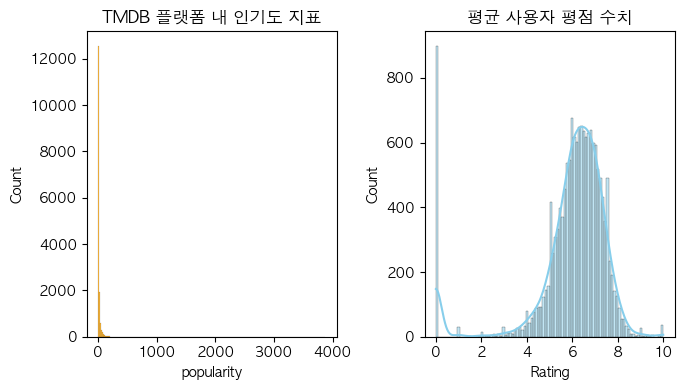

In [94]:
plt.figure(figsize=(7, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['popularity'], color="orange")
plt.title("TMDB 플랫폼 내 인기도 지표")

plt.subplot(1,2,2)
sns.histplot(df["vote_average"], kde=True, color="skyblue")
plt.title("평균 사용자 평점 수치")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

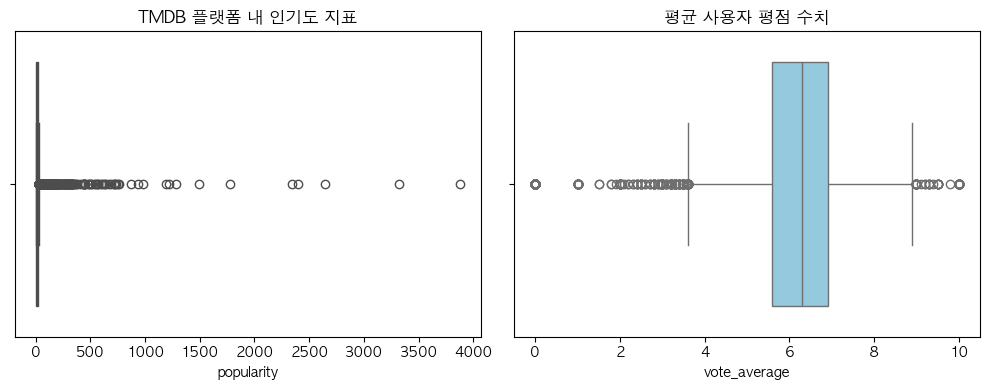

In [100]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x=df['popularity'], color="orange")
plt.title("TMDB 플랫폼 내 인기도 지표")

plt.subplot(1, 2, 2)
sns.boxplot(x=df['vote_average'], color="skyblue")
plt.title("평균 사용자 평점 수치")

plt.tight_layout()
plt.show()


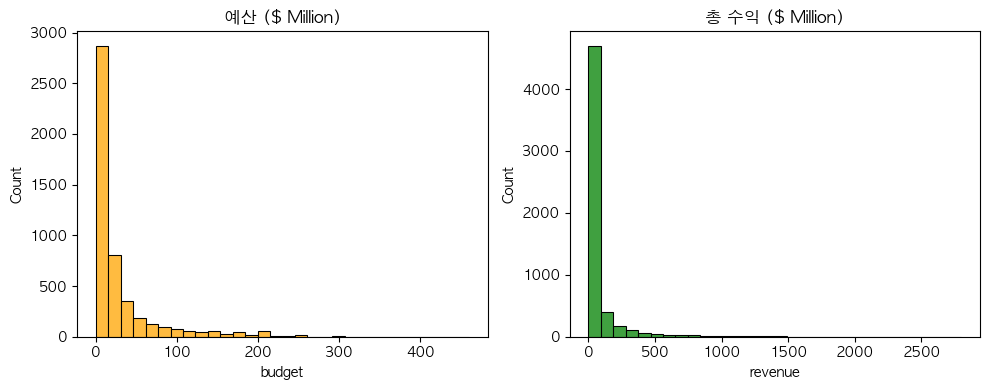

In [97]:
budget_positive = df[df["budget"] > 0]["budget"] / 1000000
revenue_positive = df[df["revenue"] > 0]["revenue"] / 1000000

plt.figure(figsize=(10, 4))

# 예산 분포
plt.subplot(1, 2, 1)
sns.histplot(budget_positive, bins=30, color="orange")
plt.title("예산 ($ Million)")

# 수익 분포
plt.subplot(1, 2, 2)
sns.histplot(revenue_positive, bins=30, color="green")
plt.title("총 수익 ($ Million)")

plt.tight_layout()
plt.show()

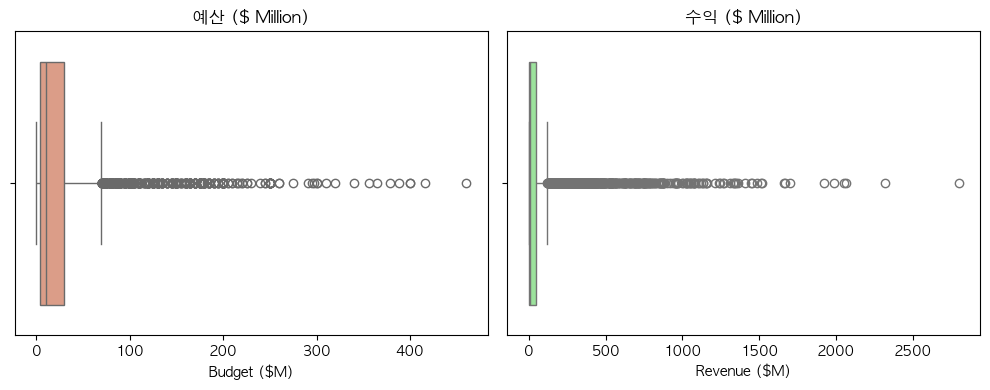

In [98]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x=budget_positive, color="darksalmon")
plt.title("예산 ($ Million)")
plt.xlabel("Budget ($M)")

plt.subplot(1, 2, 2)
sns.boxplot(x=revenue_positive, color="lightgreen")
plt.title("수익 ($ Million)")
plt.xlabel("Revenue ($M)")

plt.tight_layout()
plt.show()

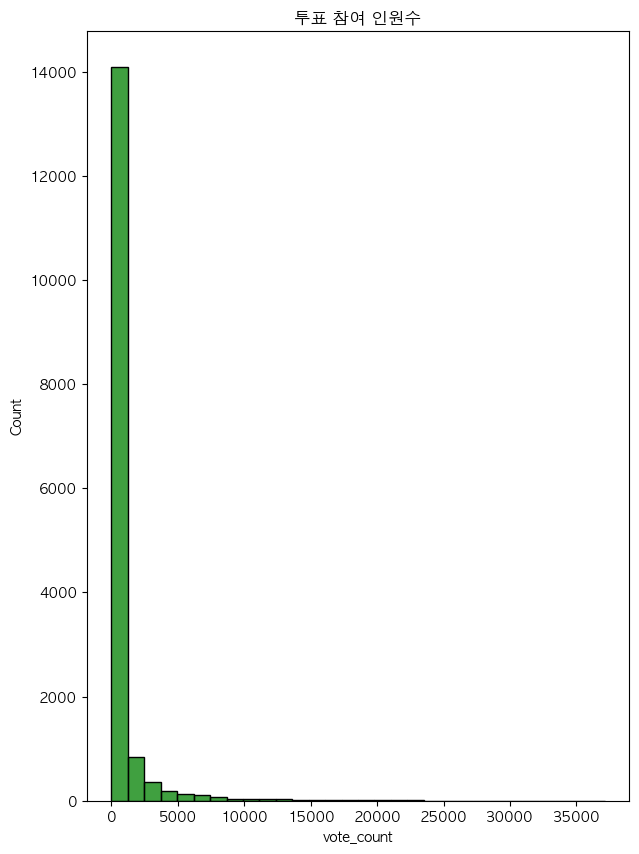

In [93]:
plt.figure(figsize=(7,10))

sns.histplot(df['vote_count'], bins=30, color="green")
plt.title("투표 참여 인원수")

plt.show()

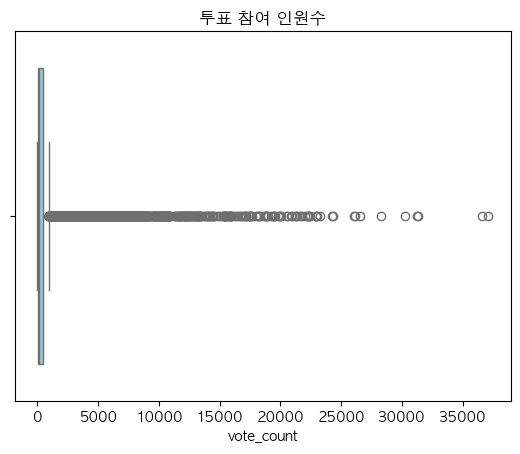

In [101]:
sns.boxplot(x=df['vote_count'], color="skyblue")
plt.title("투표 참여 인원수")

plt.show()

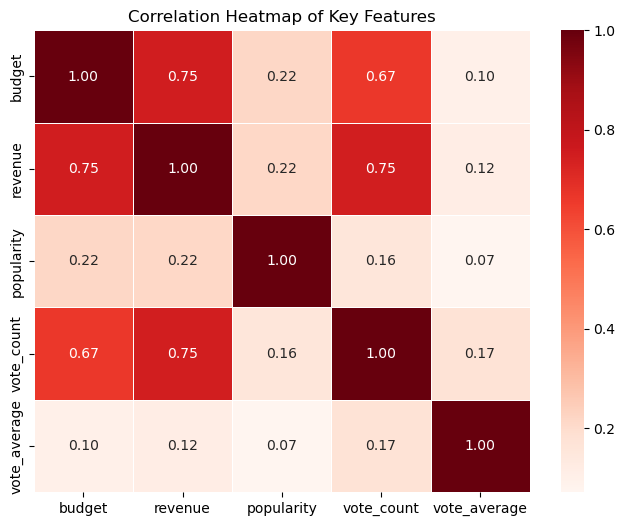

In [68]:
# 상관관계 분석에 사용할 주요 수치형 컬럼 선택
cols = ["budget", "revenue", "popularity", "vote_count", "vote_average"]
corr_matrix = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="Reds", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Key Features")
plt.show()

=== 클래스별 데이터 개수 ===
is_profitable
0    2611
1    2236
Name: count, dtype: int64

=== 클래스별 비율 (%) ===
is_profitable
0    53.87
1    46.13
Name: proportion, dtype: float64


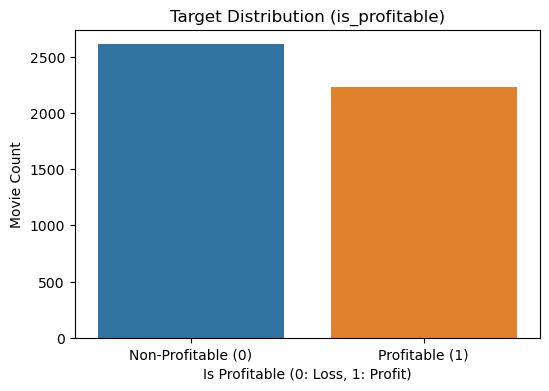

In [86]:
df_valid = df[df["budget"] > 0].copy()
df_valid["is_profitable"] = (
    df_valid["revenue"] > df_valid["budget"]
).astype(int)

# 1. 수치 및 비율 확인
print("=== 클래스별 데이터 개수 ===")
print(df_valid["is_profitable"].value_counts())
print("\n=== 클래스별 비율 (%) ===")
print(
    df_valid["is_profitable"].value_counts(normalize=True).round(4) * 100
)

# 2. 클래스 분포 시각화 (막대 그래프)
plt.figure(figsize=(6, 4))
sns.countplot(
    x="is_profitable", data=df_valid, hue= "is_profitable", legend=False
)
plt.title("Target Distribution (is_profitable)")
plt.xlabel("Is Profitable (0: Loss, 1: Profit)")
plt.ylabel("Movie Count")
plt.xticks([0, 1], ["Non-Profitable (0)", "Profitable (1)"])
plt.show()

In [108]:
len(df[(df["budget"] > 0) & (df['revenue']!=0)])

3540